# Notebook 00c: City & Time Period Selection

## Overview
This notebook reads the missingness CSV produced by **Notebook 00b** and applies
user-defined quality thresholds to decide:
1. **Which cities** have sufficient data coverage to be included in the analysis
2. **Which date ranges** within those cities contain enough good data to be worth downloading

Results are exported as a structured JSON file consumed by **Notebook 00d** to trigger
the actual GEE downloads.

## 0 · Initialisation

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import sys
import json
import warnings
from pathlib import Path
from datetime import date, timedelta

# ── Third-party ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Project config ────────────────────────────────────────────────────────────
SRC_PATH = Path().resolve().parent / 'src'
sys.path.append(str(SRC_PATH))
from config import DATA_PATH

MISSINGNESS_DIR = DATA_PATH / 'missingness'
print(f'Missingness dir : {MISSINGNESS_DIR}')

Missingness dir : /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/missingness


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ── USER INPUTS  (edit this cell) ────────────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# ── Input CSV (output from Notebook 00a) ─────────────────────────────────────
# Must be within the START_DATE / END_DATE used in 00a.
START_DATE = '2025-01-01'
END_DATE   = '2025-12-31'

# ── Variables to evaluate ─────────────────────────────────────────────────────
# List the variable names (as they appear in the CSV 'variable' column) that
# you want to assess and export date ranges for.
# Comment out any variable you do not wish to include in the output JSON.
VARIABLES_TO_ASSESS = [
    'no2',
    # 'era5_temp',
    # 'ntl',
]

# ── Threshold 1: daily pixel quality ─────────────────────────────────────────
# A day is considered GOOD for a city×variable if the percentage of valid
# (non-NaN) pixels within the bounding box is at or above this value.
# Range: 0–100. Higher = stricter daily quality requirement.
# Recommendation: 70 for optical/radar products (cloud-affected);
#                 lower (e.g. 50) for reanalysis products like ERA5.
MIN_DAILY_VALID_PCT = 1.0 # set to 1% to allow as many non-fully-empty days as possible.

# ── Threshold 2: annual coverage ──────────────────────────────────────────────
# A city×variable is INCLUDED only if at least this fraction of days in the
# assessed period are GOOD (as defined by Threshold 1).
# Range: 0–100. Example: 40 means at least 40% of days must be good.
# This is evaluated over the total period present in the CSV (not necessarily
# a full calendar year — so partial-year CSVs are handled correctly).
MIN_YEAR_COVERAGE_PCT = 35.0

# ── Threshold 3: minimum contiguous good days ─────────────────────────────────
# A contiguous run of good days is only kept if it contains at least this many
# consecutive good days. Shorter runs are discarded entirely.
#
# Rationale:
#   - Lag features: if you plan to use lag-N features, set this to at least N+1.
#     Example: lag-3 NO₂ requires min 4 consecutive days.
#   - Weekly aggregation: set to at least 14 to guarantee ≥2 complete weeks.
#   - Set to 1 to keep all good days (no minimum run length enforced).
MIN_CONTIGUOUS_DAYS = 1 # since we are not using lag features, we can set this to 1 to keep all good days.

# ── Gap tolerance (advanced — leave at 0 for clean ranges) ───────────────────
# Number of consecutive BAD days allowed within a run before it is split.
# At 0: any bad day immediately breaks the run (recommended).
# At N>0: up to N bad days are bridged — those bad days ARE included in the
#   exported date range, meaning 00c will attempt to download them (and will
#   get empty/partial tiles).
GAP_TOLERANCE = 0

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
# ── Derived paths ─────────────────────────────────────────────────────────────
INPUT_CSV   = MISSINGNESS_DIR / f'missingness_{START_DATE}_{END_DATE}.csv'
OUTPUT_JSON = MISSINGNESS_DIR / f'selected_periods_{START_DATE}_{END_DATE}.json'

assert INPUT_CSV.exists(), f'Input CSV not found: {INPUT_CSV}\nRun Notebook 00a first.'

print(f'Input CSV   : {INPUT_CSV}')
print(f'Output JSON : {OUTPUT_JSON}')

Input CSV   : /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/missingness/missingness_2025-01-01_2025-12-31.csv
Output JSON : /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/missingness/selected_periods_2025-01-01_2025-12-31.json


---
## 1 · Load & Validate Missingness Data

In [4]:
# ── Load CSV ──────────────────────────────────────────────────────────────────
df = pd.read_csv(INPUT_CSV, parse_dates=['date'])
df = df.sort_values(['city', 'variable', 'date']).reset_index(drop=True)

# ── Basic validation ──────────────────────────────────────────────────────────
all_cities    = sorted(df['city'].unique())
all_variables = sorted(df['variable'].unique())
total_days    = (df['date'].max() - df['date'].min()).days + 1

print(f'Rows loaded    : {len(df):,}')
print(f'Cities found   : {all_cities}')
print(f'Variables found: {all_variables}')
print(f'Date range     : {df["date"].min().date()} → {df["date"].max().date()} ({total_days} days)')

# Warn if requested variables are not in the CSV
missing_vars = [v for v in VARIABLES_TO_ASSESS if v not in all_variables]
if missing_vars:
    print(f'\nWARNING: These variables are not in the CSV and will be skipped: {missing_vars}')

# Filter to only the variables the user wants to assess
VARIABLES_TO_ASSESS = [v for v in VARIABLES_TO_ASSESS if v in all_variables]
df = df[df['variable'].isin(VARIABLES_TO_ASSESS)].copy()
print(f'\nAssessing      : {VARIABLES_TO_ASSESS}')

Rows loaded    : 6,205
Cities found   : ['abuja', 'algiers', 'baghdad', 'buenos_aires', 'cairo', 'cape_town', 'cebu', 'dakar', 'lima', 'los_angeles', 'madrid', 'mexico_city', 'mumbai', 'nairobi', 'new_york', 'santiago', 'yangon']
Variables found: ['no2']
Date range     : 2025-01-01 → 2025-12-31 (365 days)

Assessing      : ['no2']


---
## 2 · Selection Functions

In [5]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SELECTION FUNCTIONS  (do not edit)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def extract_contiguous_runs(
    good_dates      : pd.Series,
    gap_tolerance   : int,
    min_contiguous  : int,
) -> list:
    """
    Extract contiguous runs of good dates from a sorted Series of dates.

    A run is a maximal sequence of good dates where consecutive dates are
    separated by at most (gap_tolerance + 1) days. At gap_tolerance=0,
    any missing day breaks the run immediately.

    Only runs with at least `min_contiguous` days are returned.

    Parameters
    ----------
    good_dates     : sorted pd.Series of datetime64 dates that passed the
                     daily valid pixel threshold
    gap_tolerance  : max consecutive bad days allowed within a run (0 = strict)
    min_contiguous : minimum number of good days a run must contain to be kept

    Returns
    -------
    List of dicts: [{'start': 'YYYY-MM-DD', 'end': 'YYYY-MM-DD', 'n_days': int}, ...]
    where 'start' and 'end' are the first and last GOOD day in the run
    (bad days bridged by gap_tolerance are NOT included in start/end).
    """
    if good_dates.empty:
        return []

    dates  = pd.to_datetime(good_dates).sort_values().reset_index(drop=True)
    runs   = []     # list of (run_start, run_end, n_good_days)

    run_start    = dates.iloc[0]
    run_end      = dates.iloc[0]
    n_good       = 1
    gap_buffer   = 0   # consecutive bad days seen since last good day

    for i in range(1, len(dates)):
        gap = (dates.iloc[i] - dates.iloc[i - 1]).days - 1  # bad days between consecutive good days

        if gap <= gap_tolerance:
            # Within tolerance — extend the current run
            run_end    = dates.iloc[i]
            n_good    += 1
            gap_buffer = 0
        else:
            # Gap too large — close current run, start new one
            runs.append((run_start, run_end, n_good))
            run_start  = dates.iloc[i]
            run_end    = dates.iloc[i]
            n_good     = 1
            gap_buffer = 0

    # Close the final run
    runs.append((run_start, run_end, n_good))

    # Filter by minimum contiguous days and format output
    result = [
        {
            'start' : start.strftime('%Y-%m-%d'),
            'end'   : end.strftime('%Y-%m-%d'),
            'n_days': n_good,
        }
        for start, end, n_good in runs
        if n_good >= min_contiguous
    ]

    return result


def select_city_periods(
    df              : pd.DataFrame,
    variable        : str,
    city            : str,
    min_daily_pct   : float,
    min_coverage_pct: float,
    gap_tolerance   : int,
    min_contiguous  : int,
    verbose         : bool = True,
) -> list | None:
    """
    Apply selection thresholds for one city × variable combination.

    Steps:
      1. Filter rows for this city × variable.
      2. Label each day as good (valid_pct >= min_daily_pct) or bad.
      3. Check if the fraction of good days >= min_coverage_pct → city included.
      4. Extract contiguous runs of good days.
      5. Discard runs shorter than min_contiguous days.

    Parameters
    ----------
    df               : full missingness DataFrame
    variable         : variable name string
    city             : city name string
    min_daily_pct    : minimum valid_pct to consider a day good (0–100)
    min_coverage_pct : minimum % of total days that must be good (0–100)
    gap_tolerance    : max consecutive bad days bridged within a run
    min_contiguous   : minimum consecutive good days for a run to be kept
    verbose          : if True, print a summary for this city × variable

    Returns
    -------
    List of date range dicts if the city passes, None if it fails.
    """
    sub = df[(df['city'] == city) & (df['variable'] == variable)].copy()

    if sub.empty:
        if verbose:
            print(f'  {city:15s} → NO DATA in CSV')
        return None

    total_days  = len(sub)
    sub['good'] = sub['valid_pct'] >= min_daily_pct
    n_good      = sub['good'].sum()
    coverage    = 100.0 * n_good / total_days

    # ── Threshold 2: annual coverage check ───────────────────────────────────
    passes = coverage >= min_coverage_pct

    if not passes:
        if verbose:
            print(
                f'  {city:15s} → EXCLUDED  '
                f'| good days: {n_good}/{total_days} ({coverage:.1f}%) '
                f'< threshold {min_coverage_pct}%'
            )
        return None

    # ── Extract contiguous runs ───────────────────────────────────────────────
    good_dates = sub.loc[sub['good'], 'date']
    runs = extract_contiguous_runs(good_dates, gap_tolerance, min_contiguous)

    # Total good days across kept runs
    days_in_runs = sum(r['n_days'] for r in runs)

    if verbose:
        status = 'INCLUDED' if runs else 'EXCLUDED (no runs meet min contiguous)'
        print(
            f'  {city:15s} → {status:45s} '
            f'| good days: {n_good}/{total_days} ({coverage:.1f}%) '
            f'| runs kept: {len(runs)} '
            f'| days in runs: {days_in_runs}'
        )
        for r in runs:
            print(f'      {r["start"]} → {r["end"]}  ({r["n_days"]} days)')

    return runs if runs else None


print('Selection functions loaded.')

Selection functions loaded.


---
## 3 · Apply Thresholds & Build Selection

In [6]:
# ── Run selection for all variables × cities ──────────────────────────────────
# selected_periods structure:
#   { variable: { city: [ {start, end, n_days}, ... ] } }
# Only cities that pass both thresholds and have at least one kept run appear.

selected_periods = {}

for var in VARIABLES_TO_ASSESS:
    print(f'\n══ Variable: {var.upper()} ══════════════════════════════════════════════')
    print(
        f'  Thresholds → daily valid ≥ {MIN_DAILY_VALID_PCT}%  |  '
        f'year coverage ≥ {MIN_YEAR_COVERAGE_PCT}%  |  '
        f'min contiguous days = {MIN_CONTIGUOUS_DAYS}  |  '
        f'gap tolerance = {GAP_TOLERANCE}\n'
    )

    selected_periods[var] = {}

    for city in all_cities:
        runs = select_city_periods(
            df               = df,
            variable         = var,
            city             = city,
            min_daily_pct    = MIN_DAILY_VALID_PCT,
            min_coverage_pct = MIN_YEAR_COVERAGE_PCT,
            gap_tolerance    = GAP_TOLERANCE,
            min_contiguous   = MIN_CONTIGUOUS_DAYS,
            verbose          = True,
        )
        if runs is not None:
            selected_periods[var][city] = runs

    n_included = len(selected_periods[var])
    print(f'\n  → {n_included}/{len(all_cities)} cities included for {var}')

print('\n══ Selection complete ══════════════════════════════════════════════════')


══ Variable: NO2 ══════════════════════════════════════════════
  Thresholds → daily valid ≥ 1.0%  |  year coverage ≥ 35.0%  |  min contiguous days = 1  |  gap tolerance = 0

  abuja           → INCLUDED                                      | good days: 285/365 (78.1%) | runs kept: 43 | days in runs: 285
      2025-01-01 → 2025-03-25  (84 days)
      2025-03-27 → 2025-04-09  (14 days)
      2025-04-11 → 2025-04-24  (14 days)
      2025-04-27 → 2025-04-28  (2 days)
      2025-04-30 → 2025-04-30  (1 days)
      2025-05-02 → 2025-05-16  (15 days)
      2025-05-19 → 2025-05-26  (8 days)
      2025-05-28 → 2025-06-02  (6 days)
      2025-06-04 → 2025-06-12  (9 days)
      2025-06-14 → 2025-06-22  (9 days)
      2025-06-24 → 2025-06-27  (4 days)
      2025-06-29 → 2025-07-03  (5 days)
      2025-07-06 → 2025-07-06  (1 days)
      2025-07-08 → 2025-07-08  (1 days)
      2025-07-10 → 2025-07-12  (3 days)
      2025-07-14 → 2025-07-14  (1 days)
      2025-07-18 → 2025-07-18  (1 days)
      202

---
## 4 · Export JSON

In [7]:
# ── Strip n_days from JSON output (internal use only) ─────────────────────────
# n_days is useful for inspection above but not needed by 00c.
# The JSON keeps only 'start' and 'end' per range for clean consumption.
json_output = {
    var: {
        city: [{'start': r['start'], 'end': r['end']} for r in runs]
        for city, runs in cities.items()
    }
    for var, cities in selected_periods.items()
}

# ── Also store the thresholds used, for traceability ─────────────────────────
json_output['_metadata'] = {
    'source_csv'          : str(INPUT_CSV.name),
    'start_date'          : START_DATE,
    'end_date'            : END_DATE,
    'min_daily_valid_pct' : MIN_DAILY_VALID_PCT,
    'min_year_coverage_pct': MIN_YEAR_COVERAGE_PCT,
    'min_contiguous_days' : MIN_CONTIGUOUS_DAYS,
    'gap_tolerance'       : GAP_TOLERANCE,
}

with open(OUTPUT_JSON, 'w') as f:
    json.dump(json_output, f, indent=2)

print(f'Selected periods saved → {OUTPUT_JSON}')
print(json.dumps(
    {k: v for k, v in json_output.items() if k != '_metadata'},
    indent=2
))

Selected periods saved → /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/missingness/selected_periods_2025-01-01_2025-12-31.json
{
  "no2": {
    "abuja": [
      {
        "start": "2025-01-01",
        "end": "2025-03-25"
      },
      {
        "start": "2025-03-27",
        "end": "2025-04-09"
      },
      {
        "start": "2025-04-11",
        "end": "2025-04-24"
      },
      {
        "start": "2025-04-27",
        "end": "2025-04-28"
      },
      {
        "start": "2025-04-30",
        "end": "2025-04-30"
      },
      {
        "start": "2025-05-02",
        "end": "2025-05-16"
      },
      {
        "start": "2025-05-19",
        "end": "2025-05-26"
      },
      {
        "start": "2025-05-28",
        "end": "2025-06-02"
      },
      {
        "start": "2025-06-04",
        "end": "2025-06-12"
      },
      {
        "start": "2025-06-14",
        "end": "2025-06-22"
      },
      {
        "start": "2025-06-

---
## 5 · Visualisation

Two plots per variable:
1. **Coverage bar chart** — % of good days per city, with thresholds marked
2. **Timeline plot** — selected date ranges per city overlaid on the full period

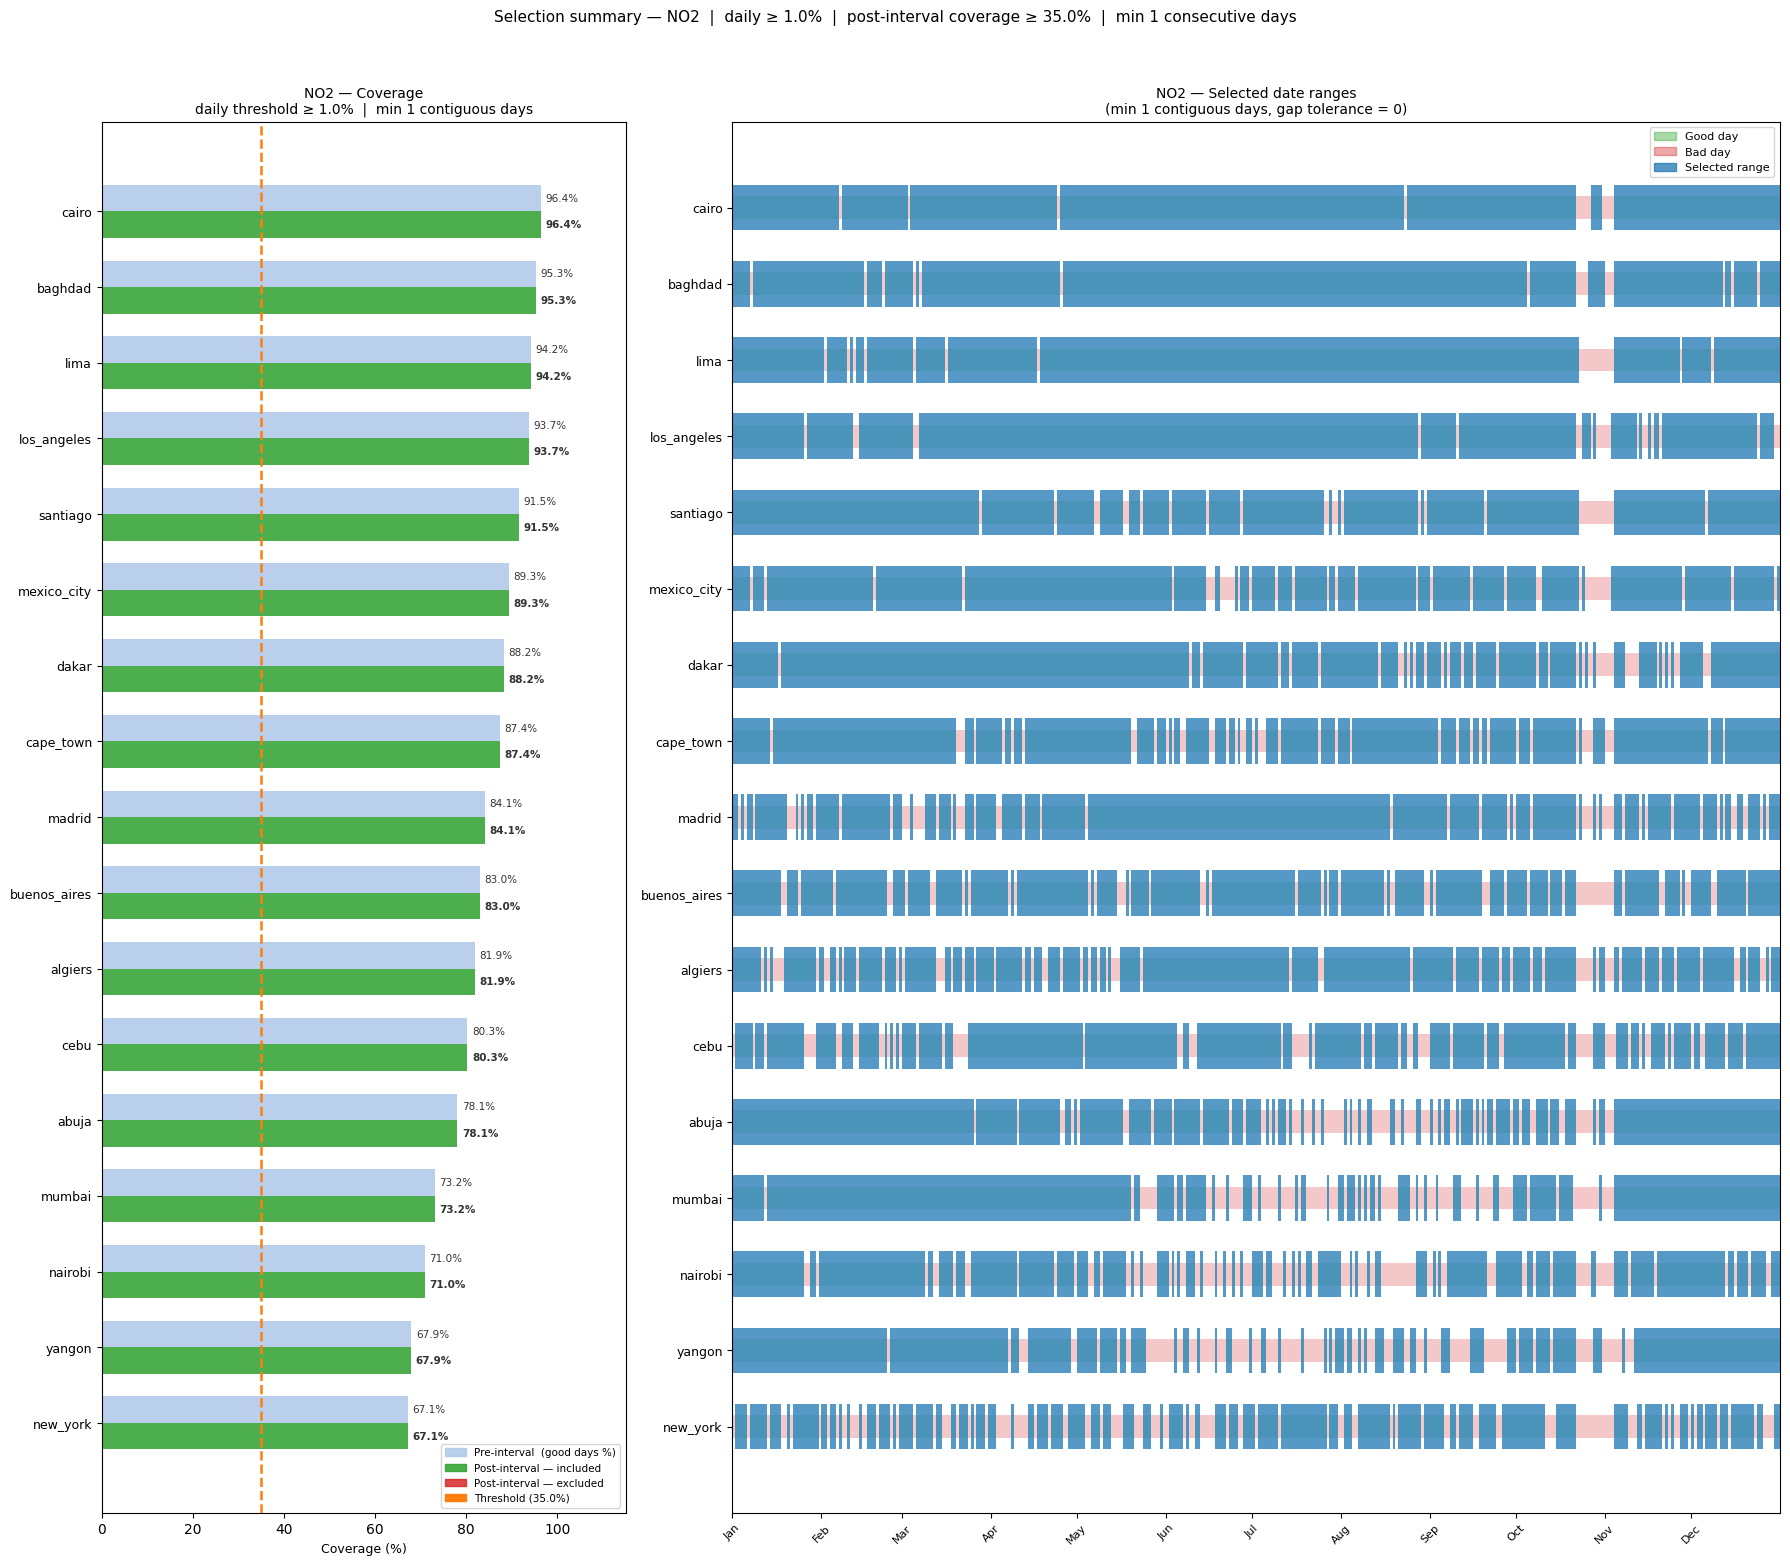

Saved → /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/missingness/selection_no2_2025-01-01_2025-12-31.pdf


In [8]:
# ── Colour palette ────────────────────────────────────────────────────────────
COL_PASS   = '#2ca02c'   # green  — city included
COL_FAIL   = '#d62728'   # red    — city excluded
COL_GOOD   = '#2ca02c'   # green  — good day
COL_BAD    = '#d62728'   # red    — bad day
COL_RANGE  = '#1f77b4'   # blue   — selected range
COL_THRESH = '#ff7f0e'   # orange — threshold line
COL_PRE    = '#aec7e8'   # light blue — pre-interval bar

period_start = pd.Timestamp(START_DATE)
period_end   = pd.Timestamp(END_DATE)
total_days   = (period_end - period_start).days + 1

for var in VARIABLES_TO_ASSESS:
    df_var         = df[df['variable'] == var].copy()
    df_var['good'] = df_var['valid_pct'] >= MIN_DAILY_VALID_PCT

    # ── Per-city coverage stats ───────────────────────────────────────────────
    # Pre-interval: fraction of days with valid_pct >= MIN_DAILY_VALID_PCT
    # Post-interval: fraction of days kept in runs that passed MIN_CONTIGUOUS_DAYS
    # Both are expressed as % of total days in the CSV period.
    coverage_stats = (
        df_var.groupby('city')['good']
        .agg(n_good='sum', n_total='count')
        .assign(pre_pct=lambda x: 100 * x['n_good'] / x['n_total'])
        .reset_index()
    )

    def post_pct(city):
        """Days kept in valid runs / total days — evaluated after MIN_CONTIGUOUS_DAYS filter."""
        runs      = selected_periods.get(var, {}).get(city, [])
        days_kept = sum(r['n_days'] for r in runs)
        n_total   = len(df_var[df_var['city'] == city])
        return 100.0 * days_kept / n_total if n_total > 0 else 0.0

    coverage_stats['post_pct'] = coverage_stats['city'].apply(post_pct)
    coverage_stats['passes']   = coverage_stats['post_pct'] >= MIN_YEAR_COVERAGE_PCT
    coverage_stats             = coverage_stats.sort_values('pre_pct', ascending=True).reset_index(drop=True)

    n_cities = len(coverage_stats)
    fig, axes = plt.subplots(
        1, 2,
        figsize     = (18, max(4, n_cities * 0.9)),
        gridspec_kw = {'width_ratios': [1, 2]},
    )

    # ── LEFT: dual horizontal bar chart (pre vs post interval coverage) ───────
    ax     = axes[0]
    height = 0.35
    y_pos  = range(n_cities)

    # Pre-interval bars (light blue, upper position in each pair)
    ax.barh(
        [y + height / 2 for y in y_pos],
        coverage_stats['pre_pct'],
        height = height,
        color  = COL_PRE,
        alpha  = 0.85,
        label  = 'Pre-interval (good days %)',
    )

    # Post-interval bars (green/red, lower position in each pair)
    post_colours = [COL_PASS if p else COL_FAIL for p in coverage_stats['passes']]
    ax.barh(
        [y - height / 2 for y in y_pos],
        coverage_stats['post_pct'],
        height = height,
        color  = post_colours,
        alpha  = 0.85,
        label  = 'Post-interval (kept days %)',
    )

    # Value labels — pre-interval (above bar, dark)
    for y, (_, row) in zip(y_pos, coverage_stats.iterrows()):
        ax.text(
            min(row['pre_pct'] + 1, 104),
            y + height / 2,
            f'{row["pre_pct"]:.1f}%',
            va='center', ha='left', fontsize=7.5, color='#333333',
        )
        # Post-interval label (on bar, white bold)
        ax.text(
            min(row['post_pct'] + 1, 104),
            y - height / 2,
            f'{row["post_pct"]:.1f}%',
            va='center', ha='left', fontsize=7.5,
            color='#333333', fontweight='bold',
        )

    # Threshold line (applies to post-interval)
    ax.axvline(
        MIN_YEAR_COVERAGE_PCT, color=COL_THRESH,
        linewidth=1.8, linestyle='--', zorder=5,
    )

    ax.set_xlim(0, 115)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(coverage_stats['city'], fontsize=9)
    ax.set_xlabel('Coverage (%)', fontsize=9)
    ax.set_title(
        f'{var.upper()} — Coverage\n'
        f'daily threshold ≥ {MIN_DAILY_VALID_PCT}%  |  min {MIN_CONTIGUOUS_DAYS} contiguous days',
        fontsize=10,
    )

    legend_handles = [
        mpatches.Patch(color=COL_PRE,   alpha=0.85, label='Pre-interval  (good days %)'),
        mpatches.Patch(color=COL_PASS,  alpha=0.85, label='Post-interval — included'),
        mpatches.Patch(color=COL_FAIL,  alpha=0.85, label='Post-interval — excluded'),
        mpatches.Patch(color=COL_THRESH,            label=f'Threshold ({MIN_YEAR_COVERAGE_PCT}%)'),
    ]
    ax.legend(handles=legend_handles, fontsize=7.5, loc='lower right')

    # ── RIGHT: timeline of selected ranges ────────────────────────────────────
    ax         = axes[1]
    city_order = coverage_stats['city'].tolist()   # same order as left plot

    for yi, city in enumerate(city_order):
        city_df = df_var[df_var['city'] == city].set_index('date')['good']

        # Daily good/bad background strips
        for dt, is_good in city_df.items():
            col = COL_GOOD if is_good else COL_BAD
            ax.barh(
                yi, 1, left=(dt - period_start).days,
                height=0.3, color=col, alpha=0.25, linewidth=0,
            )

        # Selected ranges overlay (only for included cities)
        if city in selected_periods.get(var, {}):
            for r in selected_periods[var][city]:
                r_start = (pd.Timestamp(r['start']) - period_start).days
                r_width = (pd.Timestamp(r['end']) - pd.Timestamp(r['start'])).days + 1
                ax.barh(
                    yi, r_width, left=r_start,
                    height=0.6, color=COL_RANGE, alpha=0.75, linewidth=0,
                )

    # x-axis: monthly ticks
    month_starts   = pd.date_range(START_DATE, END_DATE, freq='MS')
    tick_positions = [(m - period_start).days for m in month_starts]
    tick_labels    = [m.strftime('%b') for m in month_starts]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, fontsize=8, rotation=45)
    ax.set_yticks(range(n_cities))
    ax.set_yticklabels(city_order, fontsize=9)
    ax.set_xlim(0, total_days)
    ax.set_title(
        f'{var.upper()} — Selected date ranges\n'
        f'(min {MIN_CONTIGUOUS_DAYS} contiguous days, gap tolerance = {GAP_TOLERANCE})',
        fontsize=10,
    )

    legend_handles = [
        mpatches.Patch(color=COL_GOOD,  alpha=0.4,  label='Good day'),
        mpatches.Patch(color=COL_BAD,   alpha=0.4,  label='Bad day'),
        mpatches.Patch(color=COL_RANGE, alpha=0.75, label='Selected range'),
    ]
    ax.legend(handles=legend_handles, fontsize=8, loc='upper right')

    plt.suptitle(
        f'Selection summary — {var.upper()}  |  '
        f'daily ≥ {MIN_DAILY_VALID_PCT}%  |  '
        f'post-interval coverage ≥ {MIN_YEAR_COVERAGE_PCT}%  |  '
        f'min {MIN_CONTIGUOUS_DAYS} consecutive days',
        fontsize=11, y=1.02,
    )
    plt.tight_layout()

    fig_path = MISSINGNESS_DIR / f'selection_{var}_{START_DATE}_{END_DATE}.pdf'
    plt.savefig(fig_path, bbox_inches='tight')
    plt.show()
    print(f'Saved → {fig_path}')


---
## 6 · Final Summary Table

In [9]:
# ── Summary table: cities included per variable, total days selected ───────────
rows = []
for var, cities in selected_periods.items():
    for city, runs in cities.items():
        total_selected = sum(r['n_days'] for r in runs)
        rows.append({
            'variable'       : var,
            'city'           : city,
            'n_runs'         : len(runs),
            'total_good_days': total_selected,
            'first_start'    : runs[0]['start'],
            'last_end'       : runs[-1]['end'],
        })

if rows:
    summary_df = pd.DataFrame(rows)
    print('\n══ Final selection summary ══════════════════════════════════════════════')
    print(summary_df.to_string(index=False))
    print(f'\nJSON exported to: {OUTPUT_JSON}')
else:
    print('No city × variable combinations passed the thresholds.')
    print('Consider lowering MIN_DAILY_VALID_PCT, MIN_YEAR_COVERAGE_PCT, or MIN_CONTIGUOUS_DAYS.')


══ Final selection summary ══════════════════════════════════════════════
variable         city  n_runs  total_good_days first_start   last_end
     no2        abuja      43              285  2025-01-01 2025-12-31
     no2      algiers      48              299  2025-01-01 2025-12-31
     no2      baghdad      13              348  2025-01-01 2025-12-31
     no2 buenos_aires      38              303  2025-01-01 2025-12-31
     no2        cairo       7              352  2025-01-01 2025-12-31
     no2    cape_town      34              319  2025-01-01 2025-12-31
     no2         cebu      39              293  2025-01-02 2025-12-31
     no2        dakar      30              322  2025-01-01 2025-12-31
     no2         lima      11              344  2025-01-01 2025-12-31
     no2  los_angeles      14              342  2025-01-01 2025-12-29
     no2       madrid      41              307  2025-01-01 2025-12-31
     no2  mexico_city      25              326  2025-01-01 2025-12-31
     no2       